In [1]:
import shutil

import numpy as np
import drivers.receive_data_rfsoc as receiver
import matplotlib.pyplot as plt
from pathlib import Path
import time
from datetime import datetime
import os
import sys


sys.path.append("/home/rfsoc/github/RFSoC/PNR_measurement_scripts/drivers")

import receive_data_rfsoc as receiver
import find_thresholds as threshold_finder
import PNR_analysis as pnr_analyzer

### Downloading/Saving npy file for later

In [2]:
now = datetime.now()
day = now.strftime("%Y%m%d")
s_live = now.strftime("%H%M")

device_name = "Matterhorn"
detector_name = "gN2a8-10"
laser_name = "Pulsed_Laser_Source"
mean_photon_number = 0.5
measurement_type = "Signal_analysis"


N_detected = 0.8260633261176761


In [ ]:
save_dir_data = "/home/rfsoc/Documents/SNSPD_Lab_Measurements/PNR/RFSoC/" + f"{day}/" 
os.makedirs(save_dir_data, exist_ok=True)

In [ ]:
HOST = "0.0.0.0"
PORT = 65432

points_per_waveform = 16
amount_of_waveforms = 10000000   # total waveforms you expect to receive

data = receiver.receive_data(
    host=HOST,
    port=PORT,
    points_per_waveform=points_per_waveform,
    amount_of_waveforms=amount_of_waveforms
)

In [ ]:
save_path = save_dir_data + f"received_data_RAM_{mean_photon_number}.npy"
np.save(save_path, data)
print("Saved to:", save_path)

In [ ]:
plt.plot(data[:200])
plt.show()


In [ ]:
x, y = pnr_analyzer.classify(data)
plt.figure(dpi=500)
plt.hist(y, bins=2000)
plt.show()

In [3]:
data_dir = "/home/rfsoc/Documents/SNSPD_Lab_Measurements/PNR/RFSoC/20260319/received_data_RAM_3.npy"
data = np.load(data_dir)
print("Data loaded from:", data[:10])

Data loaded from: [ -76   36  136 -124 -452 -172  -68 1248 5388 9548]


In [4]:
x, y = pnr_analyzer.classify(data)

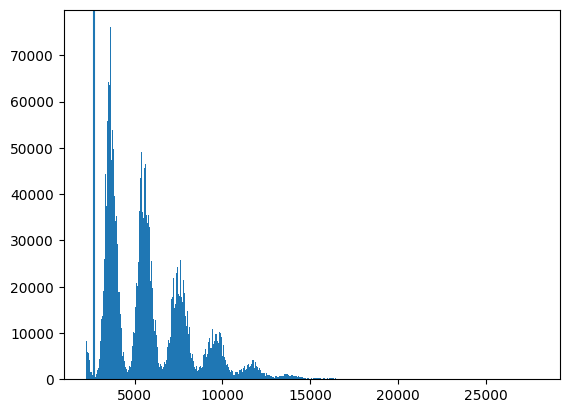

In [8]:
plt.hist(y, bins=2000)
plt.axvline(2700)

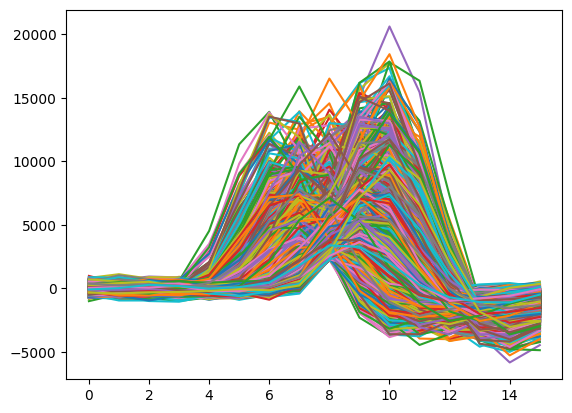

In [5]:
for i in range(10000):
    plt.plot(x[i])
plt.show()

In [17]:


threshold = 2700
thresholds_2 = 4800

under_threshold = [wf for wf in x if np.max(wf) < threshold]
between_thresholds = [wf for wf in x if threshold <= np.max(wf) < thresholds_2]
over_or_equal_threshold = [wf for wf in x if np.max(wf) >= threshold]

In [13]:
print(len(under_threshold))
print(len(over_or_equal_threshold))
print(len(under_threshold) + len(over_or_equal_threshold))

133202
9866798
10000000


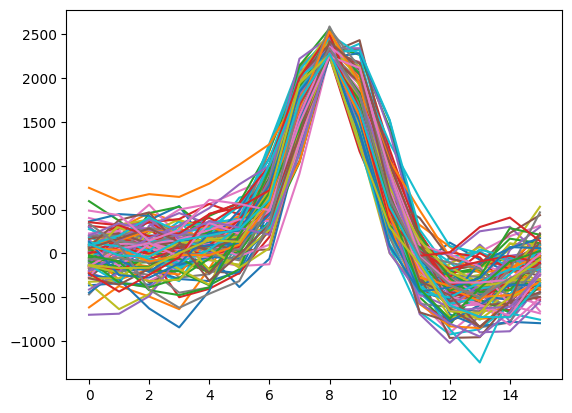

In [20]:
for i in range(100):
    plt.plot(under_threshold[i])
    # plt.plot(between_thresholds[i])
plt.show()

In [ ]:
def threshold_to_signed(x):
    return int(x) ^ 0x8000

threshold_to_signed(35600)

In [ ]:
import numpy as np

def extract_window_around_first_threshold_crossing(signal, threshold, n_before, n_after, crossing="above"):

    signal = np.asarray(signal)

    if crossing == "above":
        crossing_candidates = np.where(signal > threshold)[0]
    elif crossing == "below":
        crossing_candidates = np.where(signal < threshold)[0]
    else:
        raise ValueError("crossing must be 'above' or 'below'")

    if len(crossing_candidates) == 0:
        return None, None, None, None

    crossing_index = crossing_candidates[0]

    start_idx = max(0, crossing_index - n_before)
    end_idx = min(len(signal), crossing_index + n_after + 1)

    window = signal[start_idx:end_idx]

    return window

In [ ]:
pulses = []

for i in range(10000):
    window = extract_window_around_first_threshold_crossing(x[i], threshold=2832, n_before=3, n_after=6, crossing="above")
    pulses.append(window)

print(pulses[0])

In [ ]:
thresholds = [2.68E+03, 4.56E+03, 6.55E+03, 8.60E+03, 1.08E+04, 1.30E+04, 1.53E+04]

In [ ]:
photons = pnr_analyzer.classify_photon_number_max_ampltitude(x, thresholds)

In [ ]:
photon_number = []

for i in range(len(x)):
    max = np.max(x[i])
    if max < thresholds[0]:
        photon_number.append(0)
    elif max < thresholds[1]:
        photon_number.append(1)
    elif max < thresholds[2]:
        photon_number.append(2)
    elif max < thresholds[3]:
        photon_number.append(3)
    elif max < thresholds[4]:
        photon_number.append(4)
    elif max < thresholds[5]:
        photon_number.append(5)
    elif max < thresholds[6]:
        photon_number.append(6)
    else:
        photon_number.append(7)

print(photons[:100])

In [ ]:
dps_dir = "/mnt/qtech-serv1/RFsoc/ZCU208B/Data/20260319/Matterhorn/gN2a8-10/Pulsed_Laser_Source/1224/mu_1/dps_corrected_thresholds.csv"
dps = np.loadtxt(dps_dir, delimiter=",", skiprows=1)

In [ ]:
print(dps[:, 1])
trigger = dps[:, 2][0]
print(trigger)

In [ ]:
dps_counts = dps[:, 1][:8]

In [ ]:
print(dps_counts)

In [ ]:
true_counts = np.array([dps_counts[0]-dps_counts[1], dps_counts[1]-dps_counts[2], dps_counts[2]-dps_counts[3], dps_counts[3]-dps_counts[4], dps_counts[4]-dps_counts[5], dps_counts[5]-dps_counts[6], dps_counts[6]-dps_counts[7]]
)
print(true_counts)
print(np.sum(true_counts))

true_counts = np.insert(true_counts, 0, trigger-dps_counts[0])
print(true_counts)
print(np.sum(true_counts))


In [ ]:
fractions = true_counts / np.sum(true_counts)
print(fractions)

In [ ]:
np.savetxt("/mnt/qtech-serv1/RFsoc/ZCU208B/Data/20260319/Matterhorn/gN2a8-10/Pulsed_Laser_Source/1224/mu_1/fractions.csv", fractions, delimiter=",")